# Yelp - разведочный анализ среза (EDA_2)
### Групповой проект №5, Deep Learning, НИУ ВШЭ БИ

платформа Yelp это сервис отзывов о заведениях. берём один датасет (Yelp Open Dataset) и две связанные задачи: рекомендации и анализ отзывов, под них и делаем этот EDA.

Задача 1 - предсказать оценку stars которую юзер поставит заведению (табличные данные, полносвязные сети). Задача 2 - анализ текста отзывов (тональность, аспекты, расхождение текста и оценки).

цель тут не просто посмотреть на данные, а понять как кодировать признаки, какие архитектуры брать и какие проблемы чинить на препроцессинге (cold-start, дисбаланс классов, разреженность, не-английский текст).

срез городов обоснован в EDA_1.ipynb, данные готовят скрипты download.py и preprocess.py.

In [1]:
import re, sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(root))
from _constants import (
    PROCESSED, ARTIFACTS, ENABLE_ARTIFACTS,
    BUSINESS_PARQUET, REVIEWS_PARQUET, USERS_PARQUET, TIPS_PARQUET, META_PARQUET,
)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
NB = "EDA_2"
def savefig(name):
    if not ENABLE_ARTIFACTS:
        return
    ARTIFACTS.mkdir(parents=True, exist_ok=True)
    plt.savefig(ARTIFACTS / f"{NB}_{name}.png")
print(PROCESSED, ENABLE_ARTIFACTS)
print([p.name for p in PROCESSED.glob('*.parquet')])

C:\Users\Nikita\gp5\data\processed True
['business.parquet', 'reviews.parquet', 'task1_dataset.parquet', 'task1_embed_inputs.parquet', 'task1_features.parquet', 'task1_prior_feats.parquet', 'tips.parquet', 'users.parquet', '_meta.parquet']


## Загрузка среза
грузим подготовленные parquet-таблицы. срез это несколько выбранных городов (см. EDA_1.ipynb), он целиком влезает в память.

In [2]:
business = pd.read_parquet(BUSINESS_PARQUET)
reviews = pd.read_parquet(REVIEWS_PARQUET)
users = pd.read_parquet(USERS_PARQUET)
tips = pd.read_parquet(TIPS_PARQUET) if TIPS_PARQUET.exists() else pd.DataFrame()
meta = pd.read_parquet(META_PARQUET)
CITY = meta.loc[0, "cities"]
reviews["date"] = pd.to_datetime(reviews["date"], errors="coerce")
print(CITY)
print(len(business), len(reviews), len(users), len(tips))

Tucson, AZ + St Petersburg, FL + Edmonton, AB
17556 664751 209093 91803


это срез из нескольких городов. по порядку выводятся заведения, отзывы, юзеры и типсы. отзывы самая большая таблица, на ней всё и строится.

## Обзор датасета
масштаб, период и динамика - общий контекст для обеих задач.

In [3]:
n_users = reviews["user_id"].nunique()
n_biz = reviews["business_id"].nunique()
span = (reviews["date"].min(), reviews["date"].max())
overview = pd.DataFrame({
    "Метрика": ["Города среза", "Заведений (в срезе)", "Заведений с отзывами",
                "Уникальных юзеров", "Отзывов", "Типсов (без оценки)",
                "Период отзывов", "Средняя оценка"],
    "Значение": [CITY, f"{len(business):,}", f"{n_biz:,}",
                 f"{n_users:,}", f"{len(reviews):,}", f"{len(tips):,}",
                 f"{span[0].date()} - {span[1].date()}",
                 f"{reviews['stars'].mean():.2f}"],
})
overview

,Метрика,Значение
0,Города среза,"Tucson, AZ + St Petersburg, FL + Edmonton, AB"
1,Заведений (в срезе),"17,556"
2,Заведений с отзывами,"17,556"
3,Уникальных юзеров,"209,098"
4,Отзывов,"664,751"
5,Типсов (без оценки),"91,803"
6,Период отзывов,2005-03-02 - 2022-01-19
7,Средняя оценка,3.72


в срезе порядка 17 тысяч заведений и сотни тысяч отзывов за несколько лет. данных хватает и для рекомендателя и для анализа текста.

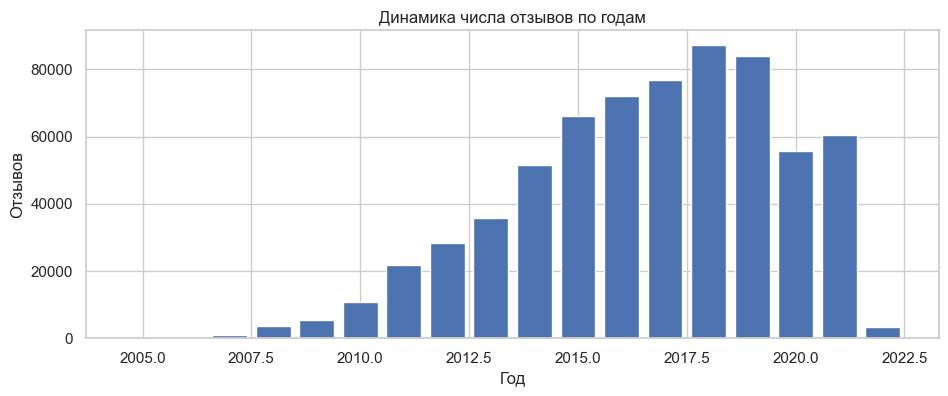

In [4]:
fig, ax = plt.subplots(figsize=(11,4))
by_year = reviews.set_index("date").resample("YE").size()
ax.bar(by_year.index.year, by_year.values)
ax.set_title("Динамика числа отзывов по годам")
ax.set_xlabel("Год"); ax.set_ylabel("Отзывов")
savefig("01_reviews_per_year"); plt.show()

число отзывов почти каждый год растёт, основная масса данных приходится на последние годы среза.

## Табличный EDA для задачи 1 (рекомендатель)

рекомендатель учится по тройкам (user, business, stars). смотрим распределение таргета, активность юзеров и популярность мест, разреженность матрицы и смещения оценок.

### Распределение таргета stars
посмотрим как распределены оценки в отзывах и средние оценки заведений.

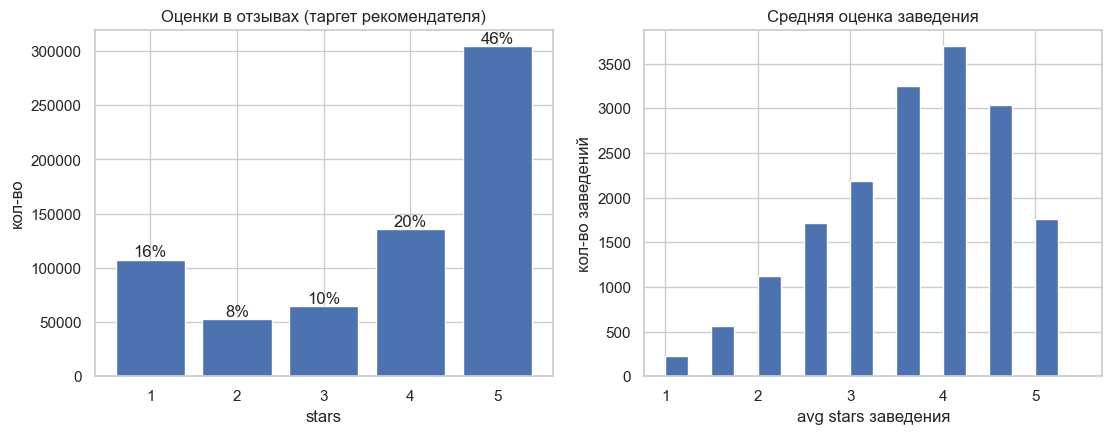

доля 4-5 среди отзывов: 0.662
средняя оценка: 3.718


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13,4.5))
vc = reviews["stars"].value_counts().sort_index()
axes[0].bar(vc.index, vc.values)
axes[0].set_title("Оценки в отзывах (таргет рекомендателя)")
axes[0].set_xlabel("stars"); axes[0].set_ylabel("кол-во")
for x,y in zip(vc.index, vc.values):
    axes[0].text(x, y, f"{y/len(reviews)*100:.0f}%", ha="center", va="bottom")
axes[1].hist(business["stars"], bins=np.arange(1,5.6,0.25))
axes[1].set_title("Средняя оценка заведения")
axes[1].set_xlabel("avg stars заведения"); axes[1].set_ylabel("кол-во заведений")
savefig("02_stars_distribution"); plt.show()
print("доля 4-5 среди отзывов:", round((reviews['stars']>=4).mean(), 3))
print("средняя оценка:", round(reviews['stars'].mean(), 3))

видно сильный перекос к 4 и 5 звёздам, классы несбалансированы. значит accuracy тут обманчива, для рекомендателя смотрим на RMSE/MAE.

### Активность юзеров и cold-start
распределение отзывов на юзера это степенной хвост, много юзеров с одним отзывом, отсюда проблема холодного старта.

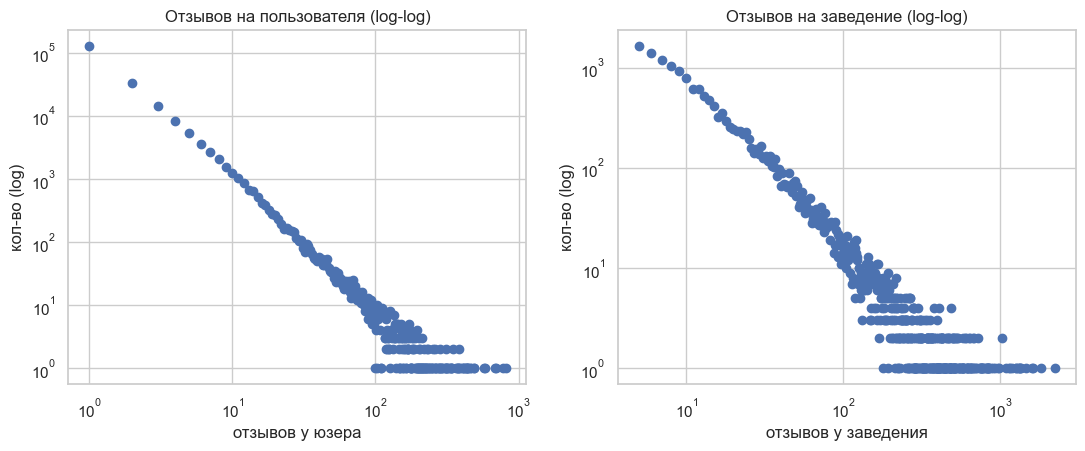

юзеров с 1 отзывом 0.61
заведений с 1 отзывом 0.0
топ 1% юзеров дают долю отзывов 0.244


In [6]:
ru = reviews.groupby("user_id").size()
rb = reviews.groupby("business_id").size()
def loglog(ax, counts, title, xlab):
    vc = counts.value_counts().sort_index()
    ax.scatter(vc.index, vc.values)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_title(title); ax.set_xlabel(xlab); ax.set_ylabel("кол-во (log)")
fig, axes = plt.subplots(1, 2, figsize=(13,4.6))
loglog(axes[0], ru, "Отзывов на пользователя (log-log)", "отзывов у юзера")
loglog(axes[1], rb, "Отзывов на заведение (log-log)", "отзывов у заведения")
savefig("03_activity_powerlaw"); plt.show()
cold_u = (ru==1).mean(); cold_b = (rb==1).mean()
print("юзеров с 1 отзывом", round(cold_u, 3))
print("заведений с 1 отзывом", round(cold_b, 3))
print("топ 1% юзеров дают долю отзывов", round(ru.sort_values().tail(int(len(ru)*0.01)).sum()/len(reviews), 3))

и у юзеров и у заведений активность это степенной хвост: большинство с одним-двумя отзывами, а небольшая верхушка даёт основную долю. для рекомендателя это холодный старт и разреженность.

### Разреженность матрицы взаимодействий
считаем плотность матрицы users x businesses и насколько неравномерно отзывы распределены по заведениям.

In [7]:
n_u, n_b, n_int = reviews["user_id"].nunique(), reviews["business_id"].nunique(), len(reviews)
density = n_int / (n_u * n_b)
top10 = rb.sort_values(ascending=False).head(int(n_b * 0.1)).sum() / n_int
density, top10

(0.00018108544650619356, np.float64(0.554594126221698))

матрица user x business заполнена на доли процента, при этом топ 10% заведений собирают основную часть отзывов. отсюда сильная разреженность и довод за обучаемые эмбеддинги вместо one-hot.

### Смещения оценок (bias)
юзеры бывают добрее или строже среднего, заведения лучше или хуже. разброс смещений показывает сколько точности даст простой baseline mu + b_user + b_item.

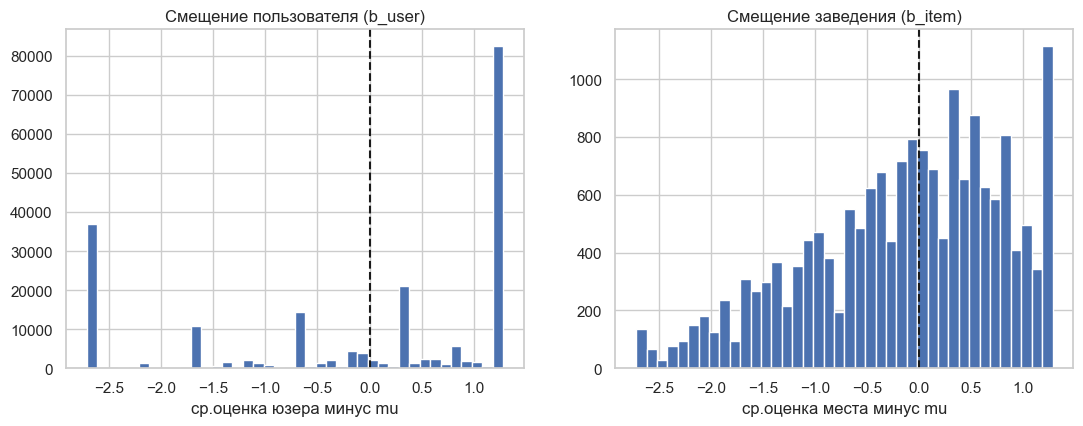

std смещения юзера 1.518
std смещения места 0.949


In [8]:
mu = reviews["stars"].mean()
ub = reviews.groupby("user_id")["stars"].mean() - mu
bb = reviews.groupby("business_id")["stars"].mean() - mu
fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
axes[0].hist(ub, bins=40)
axes[0].axvline(0, color="k", ls="--"); axes[0].set_title("Смещение пользователя (b_user)")
axes[0].set_xlabel("ср.оценка юзера минус mu")
axes[1].hist(bb, bins=40)
axes[1].axvline(0, color="k", ls="--"); axes[1].set_title("Смещение заведения (b_item)")
axes[1].set_xlabel("ср.оценка места минус mu")
savefig("04_rating_bias"); plt.show()
print("std смещения юзера", round(ub.std(), 3))
print("std смещения места", round(bb.std(), 3))

у юзеров и заведений заметный разброс смещений, кто-то систематически добрее или строже. значит простой baseline mu + b_user + b_item уже даст приличную точность, и в матричной факторизации эти bias-термы нужны.

### Признаки заведений и связь с оценкой
категории, цена и популярность - кандидаты во входные фичи. смотрим что из этого связано с оценкой.

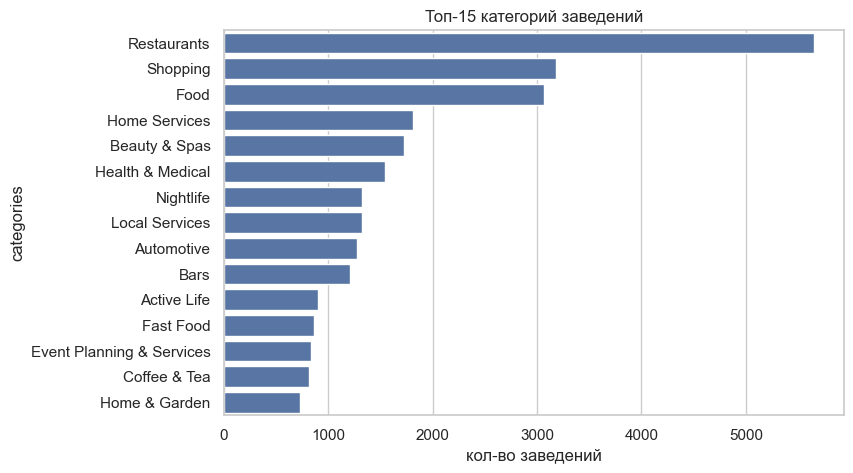

In [9]:
cats = business["categories"].dropna().str.split(", ").explode()
top_cats = cats.value_counts().head(15)
plt.figure(figsize=(8,5))
sns.barplot(x=top_cats.values, y=top_cats.index)
plt.title("Топ-15 категорий заведений"); plt.xlabel("кол-во заведений")
plt.show()

в срезе преобладают рестораны, кафе и бары, категории сильно пересекаются. это кандидат в признаки заведения.

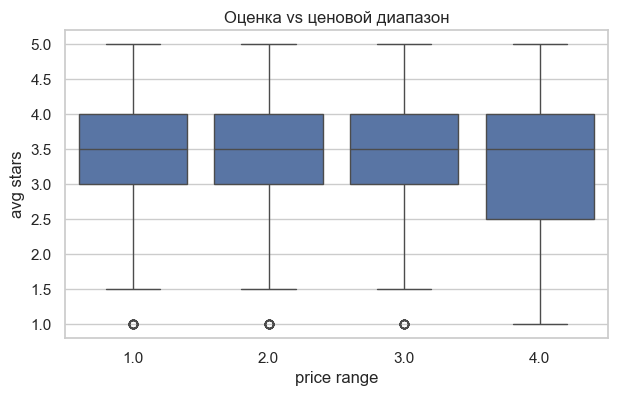

In [10]:
pr = business.dropna(subset=["price_range"])
plt.figure(figsize=(7,4))
sns.boxplot(data=pr, x="price_range", y="stars")
plt.title("Оценка vs ценовой диапазон"); plt.xlabel("price range"); plt.ylabel("avg stars")
plt.show()

разброс оценок по ценовым категориям небольшой, сильной связи цены и оценки не видно.

In [11]:
num = reviews[["stars", "useful", "funny", "cool"]]
num.corr()["stars"].round(3)

stars     1.000
useful   -0.116
funny    -0.065
cool      0.093
Name: stars, dtype: float64

голоса useful/funny/cool почти не коррелируют с оценкой отзыва, как признаки для предсказания оценки они слабые.

## Текстовый EDA для задачи 2 (анализ отзывов)

готовим почву для NLP: длина текста, баланс классов тональности, словарь, отличительные слова, аспекты, сигнал расхождения текста и оценки, язык.

### Длина отзывов
определяет max_len и стоимость обучения. длинные хвосты режем по перцентилю а не по максимуму.

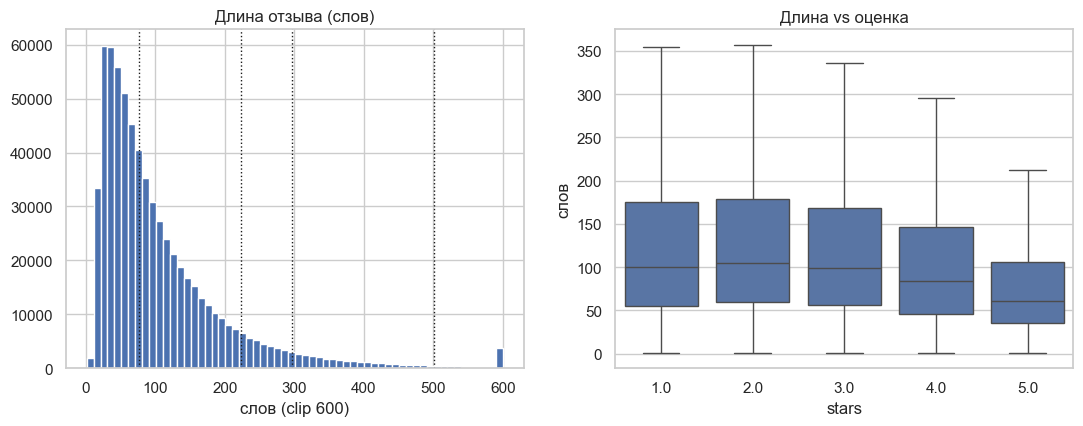

0.50     77.0
0.90    223.0
0.95    296.0
0.99    501.0
Name: n_words, dtype: float64
max_len по 95 перцентилю 296


In [12]:
reviews["n_words"] = reviews["text"].str.split().map(len)
fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
axes[0].hist(reviews["n_words"].clip(upper=600), bins=60)
axes[0].set_title("Длина отзыва (слов)"); axes[0].set_xlabel("слов (clip 600)")
for q in [0.5,0.9,0.95,0.99]:
    axes[0].axvline(reviews["n_words"].quantile(q), color="k", ls=":", lw=1)
sns.boxplot(data=reviews, x="stars", y="n_words", ax=axes[1], showfliers=False)
axes[1].set_title("Длина vs оценка"); axes[1].set_xlabel("stars"); axes[1].set_ylabel("слов")
savefig("06_text_length"); plt.show()
print(reviews["n_words"].quantile([0.5,0.9,0.95,0.99]).round())
print("max_len по 95 перцентилю", int(reviews["n_words"].quantile(0.95)))

медиана длины небольшая, но хвост длинный. по 95 перцентилю берём max_len около этого значения, остальное обрезаем.

### Баланс классов тональности
из stars делаем метку: 1-2 negative, 3 neutral, 4-5 positive. дисбаланс это повод для class weights.

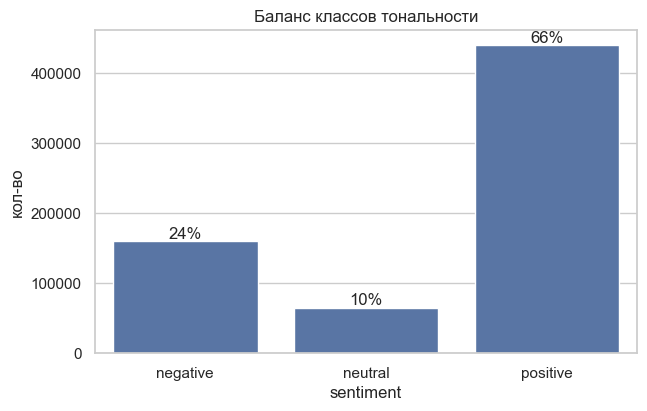

sentiment
negative    159966
neutral      64661
positive    440124
Name: count, dtype: int64
дисбаланс макс/мин 6.8


In [13]:
def to_sentiment(s):
    return np.where(s<=2,"negative", np.where(s==3,"neutral","positive"))
reviews["sentiment"] = to_sentiment(reviews["stars"])
bal = reviews["sentiment"].value_counts().reindex(["negative","neutral","positive"])
fig, ax = plt.subplots(figsize=(7,4.2))
sns.barplot(x=bal.index, y=bal.values, ax=ax)
for i,v in enumerate(bal.values): ax.text(i, v, f"{v/len(reviews):.0%}", ha="center", va="bottom")
ax.set_title("Баланс классов тональности"); ax.set_ylabel("кол-во")
savefig("07_sentiment_balance"); plt.show()
print(bal)
print("дисбаланс макс/мин", round(bal.max()/bal.min(), 1))

классы сильно несбалансированы, позитивных большинство. при обучении нужны class weights и macro-F1, а не accuracy.

### Словарь и отличительные слова
размер словаря задаёт размер эмбеддинг-слоя. чтобы понять какие слова отличают плохие отзывы от хороших, просто сравним частоту слов в позитивных и негативных отзывах.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
samp = reviews.sample(150000, random_state=42)
vec = CountVectorizer(stop_words="english", min_df=20)
X = vec.fit_transform(samp["text"].fillna(""))
vocab = vec.get_feature_names_out()
len(vocab)

13928

словарь получился в районе нескольких тысяч слов, это и есть ориентир для размера эмбеддинг-слоя.

In [15]:
pos = np.asarray(X[(samp["sentiment"] == "positive").values].sum(axis=0)).ravel()
neg = np.asarray(X[(samp["sentiment"] == "negative").values].sum(axis=0)).ravel()
diff = pos / pos.sum() - neg / neg.sum()
words = pd.Series(diff, index=vocab).sort_values()
words.tail(15)

awesome       0.001945
recommend     0.001976
excellent     0.001993
tucson        0.001994
fresh         0.002117
nice          0.002496
definitely    0.003002
place         0.003455
best          0.003712
amazing       0.003735
friendly      0.003872
love          0.003959
delicious     0.004161
good          0.005122
great         0.010641
dtype: float64

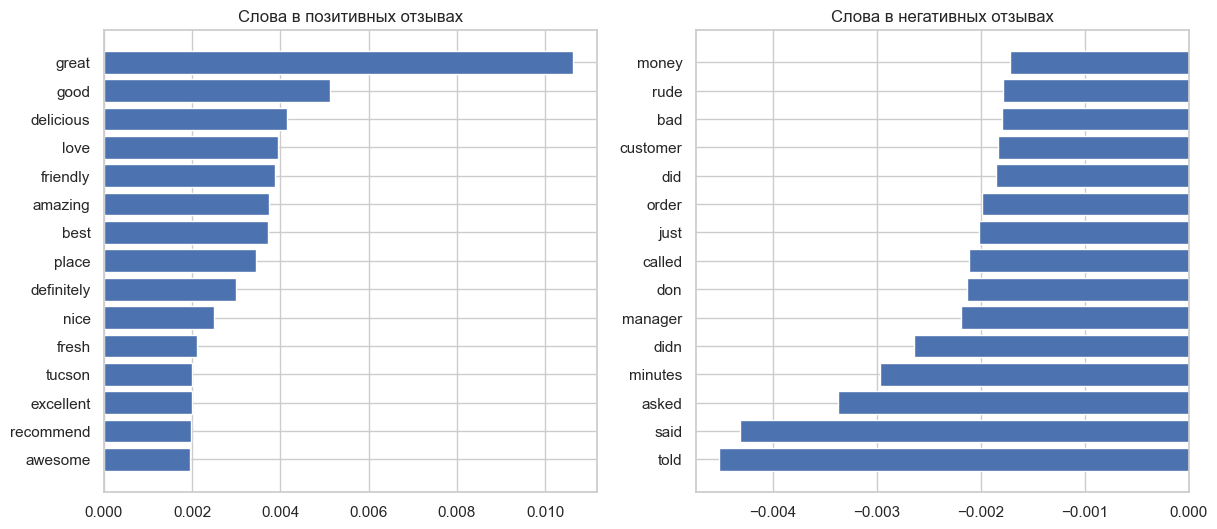

In [16]:
top_neg = words.head(15)
top_pos = words.tail(15)
fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].barh(top_pos.index, top_pos.values)
axes[0].set_title("Слова в позитивных отзывах")
axes[1].barh(top_neg.index, top_neg.values)
axes[1].set_title("Слова в негативных отзывах")
plt.show()

позитивные и негативные отзывы используют заметно разные слова, даже простое сравнение частот хорошо их разделяет. значит текст несёт сильный сигнал для модели.

### Аспекты: food / service / price
проверяем что аспектные слова реально встречаются и по-разному ведут себя в хороших и плохих отзывах.

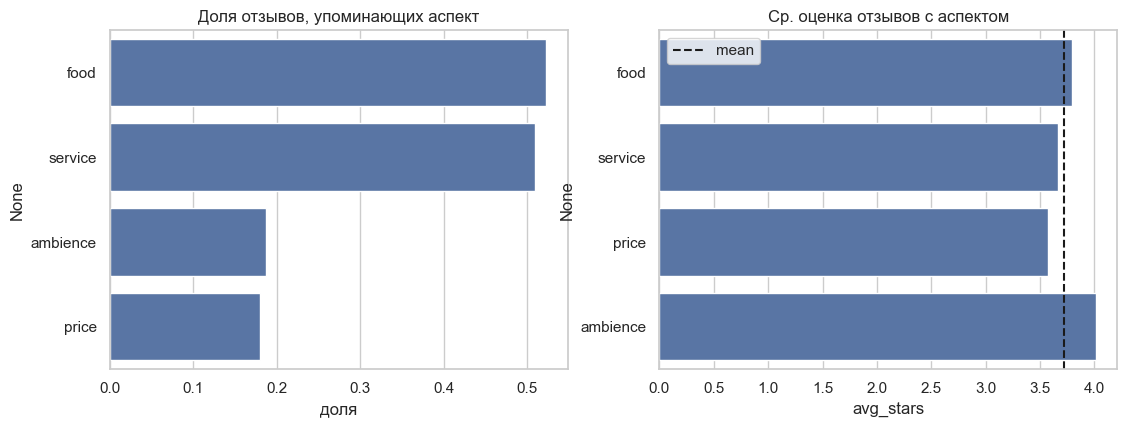

,avg_stars,share
food,3.791,0.523
service,3.669,0.510
price,3.571,0.179
ambience,4.011,0.187


In [17]:
ASPECTS = {
    "food": r"\b(food|dish|meal|taste|flavor|menu|portion|delicious|pizza|burger|chicken)\b",
    "service": r"\b(service|staff|waiter|waitress|server|manager|rude|friendly|attentive)\b",
    "price": r"\b(price|cheap|expensive|value|worth|overpriced|affordable|cost)\b",
    "ambience": r"\b(ambience|atmosphere|decor|music|cozy|noisy|clean|seating)\b",
}
asp = samp.copy()
for a, pat in ASPECTS.items():
    asp[a] = asp["text"].str.contains(pat, case=False, regex=True, na=False)
share = asp[list(ASPECTS)].mean().sort_values(ascending=False)
by_asp = pd.DataFrame({a: [asp.loc[asp[a],"stars"].mean(), asp[a].mean()] for a in ASPECTS},
                      index=["avg_stars","share"]).T
fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
sns.barplot(x=share.values, y=share.index, ax=axes[0])
axes[0].set_title("Доля отзывов, упоминающих аспект"); axes[0].set_xlabel("доля")
sns.barplot(x=by_asp["avg_stars"], y=by_asp.index, ax=axes[1])
axes[1].axvline(reviews["stars"].mean(), color="k", ls="--", label="mean")
axes[1].set_title("Ср. оценка отзывов с аспектом"); axes[1].legend()
savefig("09_aspects"); plt.show()
display(by_asp.round(3))

аспекты еда, сервис и цена реально встречаются в отзывах, и средняя оценка по ним различается. значит разбирать тональность по аспектам имеет смысл.

### Сигнал расхождения текста и оценки (детектор фейков)
простой лексиконный скор текста сравниваем со звёздами. сильные расхождения (злой текст при 5 звёздах и наоборот) это кандидаты в фейки.

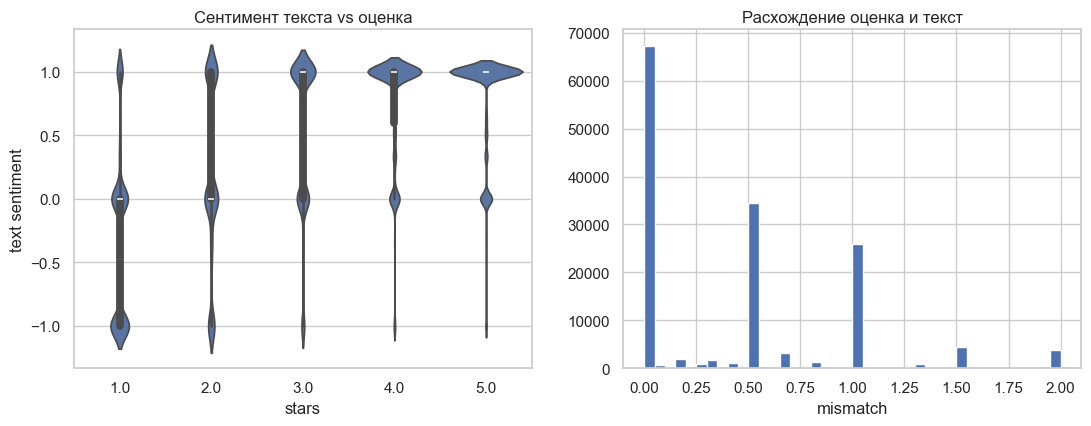

5 -1.0 Experienced a problem in my condo with American Crockroaches, helped give me temp relieve with white boxes to catch them
1 1.0 I almost forgot to write a review until I went to the Boston pizza in WEM on bourbon street there service was amazing so
1 1.0 Strike Six and counting. Stepped into the brand new Lime here at Tyrone and we were greeted by open doors and no AC. Str
доля отзывов с сильным расхождением 0.065


In [18]:
POS_LEX = set("great good love amazing best delicious excellent perfect friendly awesome wonderful fantastic".split())
NEG_LEX = set("bad worst terrible awful rude horrible disgusting slow dirty never overpriced disappointing".split())
def lex_score(t):
    w = re.findall(r"[a-z]+", str(t).lower())
    p = sum(x in POS_LEX for x in w); n = sum(x in NEG_LEX for x in w)
    return (p-n)/max(p+n,1)
samp = samp.assign(lex=samp["text"].map(lex_score))
samp["stars_norm"] = (samp["stars"]-3)/2
samp["mismatch"] = (samp["stars_norm"]-samp["lex"]).abs()
fig, axes = plt.subplots(1, 2, figsize=(13,4.4))
sns.violinplot(data=samp, x="stars", y="lex", ax=axes[0])
axes[0].set_title("Сентимент текста vs оценка"); axes[0].set_ylabel("text sentiment")
axes[1].hist(samp["mismatch"], bins=40)
axes[1].set_title("Расхождение оценка и текст"); axes[1].set_xlabel("mismatch")
savefig("10_text_star_mismatch"); plt.show()
flag = samp.sort_values("mismatch", ascending=False).head(3)
for _, r in flag.iterrows():
    print(int(r['stars']), round(r['lex'],2), str(r['text'])[:120])
print("доля отзывов с сильным расхождением", round((samp['mismatch']>1.0).mean(), 3))

у части отзывов тон текста расходится со звёздами, например злой текст при высокой оценке. таких заметная доля, и это сигнал для детектора накруток.

### Язык отзывов
модели учим на английском, остальное надо отфильтровать. оцениваем долю на сэмпле.

In [19]:
import langid
lang_samp = samp.sample(min(4000, len(samp)), random_state=1)
langs = lang_samp["text"].fillna("").map(lambda t: langid.classify(t[:400])[0])
print((langs.value_counts(normalize=True).head(6)*100).round(2))
print("доля английского", round((langs=='en').mean(), 3))

text
en    99.95
af     0.02
es     0.02
Name: proportion, dtype: float64
доля английского 1.0


почти все отзывы английские, доля других языков мизерная. их можно просто отфильтровать на препроцессинге.

### Типсы - текст без оценки
у типсов нет рейтинга, это объект для инференса обученной моделью. сравниваем их длину с отзывами.

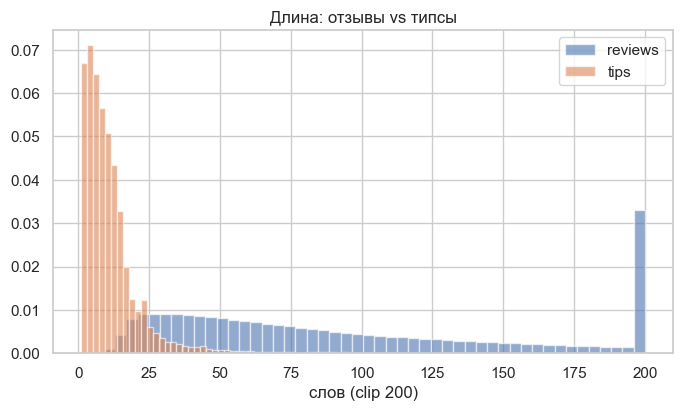

типсов без оценки 91803 медиана длины 9


In [20]:
if len(tips):
    tips["n_words"] = tips["text"].str.split().map(len)
    fig, ax = plt.subplots(figsize=(8,4.2))
    ax.hist(reviews["n_words"].clip(upper=200), bins=50, alpha=.6, density=True, label="reviews")
    ax.hist(tips["n_words"].clip(upper=200), bins=50, alpha=.6, density=True, label="tips")
    ax.legend(); ax.set_title("Длина: отзывы vs типсы"); ax.set_xlabel("слов (clip 200)")
    savefig("11_tips_vs_reviews"); plt.show()
    print("типсов без оценки", len(tips), "медиана длины", int(tips['n_words'].median()))
else:
    print("tips.parquet пуст")

типсы заметно короче отзывов и без оценки. это готовый объект чтобы прогнать обученную модель и проставить тональность.

## Качество данных
пропуски, дубликаты, повторные визиты и удалённые юзеры - то что чинится на препроцессинге.

In [21]:
print("пропуски по таблицам:")
for name, df in [("business",business),("reviews",reviews),("users",users)]:
    miss = df.isna().mean()
    miss = miss[miss>0]
    print(name, dict(miss.round(3)) if len(miss) else "нет пропусков")
dup_rev = reviews.duplicated(subset=["review_id"]).sum()
dup_pair = reviews.duplicated(subset=["user_id","business_id"]).sum()
missing_users = (~reviews["user_id"].isin(users["user_id"])).mean()
print("дубликаты review_id", dup_rev)
print("повторные пары user-business", dup_pair)
print("отзывы от удалённых юзеров", round(missing_users, 3))

пропуски по таблицам:
business {'categories': np.float64(0.001), 'price_range': np.float64(0.441)}
reviews нет пропусков
users нет пропусков


дубликаты review_id 0
повторные пары user-business 26680
отзывы от удалённых юзеров 0.0


## Выводы EDA
короткая сводка, что EDA говорит для каждой из двух задач. числа берём из ячеек выше.

In [22]:
print("Задача 1, рекомендатель.")
print(f"матрица user-item заполнена на {density:.3%}, нужны обучаемые эмбеддинги а не one-hot.")
print(f"юзеров с 1 отзывом {cold_u:.0%}, мест с 1 отзывом {cold_b:.0%}, это холодный старт, добавляем контентные фичи.")
print(f"std смещений юзер {ub.std():.2f}, место {bb.std():.2f}, отсюда bias-термы и метрика RMSE/MAE.")
print(f"перекос к 4-5 звёздам {(reviews['stars']>=4).mean():.0%}, поэтому MAE информативнее accuracy.")
print()
print("Задача 2, анализ отзывов.")
print(f"max_len около {reviews['n_words'].quantile(0.95):.0f} токенов по 95 перцентилю.")
print(f"дисбаланс тональности {bal.max()/bal.min():.1f}, нужны class weights и macro-F1.")
print(f"словарь около {len(vocab):,} слов.")
print(f"расхождение текста и оценки у {(samp['mismatch']>1.0).mean():.0%} отзывов, отсюда детектор фейков.")
print(f"английский около {(langs=='en').mean():.0%}, остальное фильтруем.")
print(f"типсов без оценки {len(tips):,}, это объект для инференса.")

Задача 1, рекомендатель.
матрица user-item заполнена на 0.018%, нужны обучаемые эмбеддинги а не one-hot.
юзеров с 1 отзывом 61%, мест с 1 отзывом 0%, это холодный старт, добавляем контентные фичи.
std смещений юзер 1.52, место 0.95, отсюда bias-термы и метрика RMSE/MAE.
перекос к 4-5 звёздам 66%, поэтому MAE информативнее accuracy.

Задача 2, анализ отзывов.
max_len около 296 токенов по 95 перцентилю.
дисбаланс тональности 6.8, нужны class weights и macro-F1.
словарь около 13,928 слов.
расхождение текста и оценки у 7% отзывов, отсюда детектор фейков.
английский около 100%, остальное фильтруем.
типсов без оценки 91,803, это объект для инференса.


### Краткие выводы для презентации

Рекомендатель. внимание на Yelp распределено очень неравномерно, большинство мест и юзеров с единичными отзывами. поэтому нужны индивидуальные векторы вкусов (эмбеддинги), а простые смещения "добрый юзер / хорошее место" уже дают честный baseline.

Анализ отзывов. звёзды огрубляют содержание: длинные отзывы есть и у довольных и у недовольных, а упоминания сервиса тянут оценку вниз сильнее чем еда. отсюда ценность аспектной тональности. часть отзывов расходится по тону с оценкой - основа для детектора накруток, а тысячи типсов без оценки ждут модель.